# TUGAS MANDIRI 3 — Praktikum Big Data
**Nama**: Dany Akhdan Imaduddin
**NIM**: 2505060062

### Instruksi Pengerjaan

Buat **notebook BARU** bernama **`Tugas3_[NIM]_[Nama Lengkap].ipynb`**, letakkan di folder `~/praktikum-bigdata` yang sama dengan ketiga berkas CSV di atas, lalu kerjakan seluruh bagian **A sampai E** berikut secara berurutan.

---

**A. Membangun Struktur Direktori HDFS** *(bobot 15%)*

Buatlah struktur direktori berikut di HDFS:
```
/user/[username]/ecommerce/raw
/user/[username]/ecommerce/processed
```
Tampilkan hasilnya untuk membuktikan struktur sudah terbentuk.

**B. Mengunggah Data Mentah ke HDFS** *(bobot 15%)*

Unggah **ketiga berkas CSV** (`transaksi_magelang.csv`, `transaksi_yogyakarta.csv`, `transaksi_semarang.csv`) ke direktori `/user/[username]/ecommerce/raw` di HDFS. Tampilkan isi direktori tersebut sebagai bukti ketiga berkas berhasil terunggah, lengkap dengan ukurannya.

**C. Membaca Kembali dan Menggabungkan Data dari HDFS** *(bobot 25%)*

Menggunakan Python, baca kembali **ketiga berkas dari HDFS** (bukan dari disk lokal!). Gabungkan ketiganya menjadi **satu DataFrame**, lalu buktikan hasil gabungan berisi transaksi dari ketiga kota (tampilkan `value_counts()` pada kolom `kota`).

**D. Mengolah dan Download Hasil ke Direktori `processed`** *(bobot 25%)*

Pada DataFrame gabungan hasil bagian C:
1. Tambahkan kolom `total_pendapatan` (`unit_terjual x harga_satuan`).
2. Buatlah **satu tabel ringkasan** (`groupby`) yang menampilkan total pendapatan per kota **dan** per kategori sekaligus.
3. Simpan **dua** hasil berikut sebagai berkas CSV baru di disk lokal, lalu unggah keduanya ke `/user/[username]/ecommerce/processed` di HDFS:
   - `data_gabungan_bersih.csv` (seluruh data ketiga kota yang telah digabung + kolom `total_pendapatan`)
   - `ringkasan_kota_kategori.csv` (tabel ringkasan dari langkah 2)

**E. Dokumentasi dan Refleksi** *(bobot 20%)*

Sertakan pada notebook anda:
1. **Screenshot** halaman NameNode Web UI (http://localhost:9870, menu *Utilities → Browse the file system*) yang menunjukkan struktur folder `/user/[username]/ecommerce/` beserta isinya (paste gambar ke dalam markdown cell, atau lampirkan terpisah jika format pengumpulan berupa arsip/zip.
2. Tulisan reflektif (**minimal 100 kata**) pada markdown cell yang menjawab: *Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?*

---

**Jawaban:**

## A. Membangun Struktur Direktori HDFS

In [9]:
!hdfs dfs -mkdir -p /user/tugas3/ecommerce/raw
!hdfs dfs -mkdir -p /user/tugas3/ecommerce/processed

In [10]:
!hdfs dfs -ls /user/tugas3/ecommerce

Found 2 items
drwxr-xr-x   - dany supergroup          0 2026-09-09 20:58 /user/tugas3/ecommerce/processed
drwxr-xr-x   - dany supergroup          0 2026-09-09 20:58 /user/tugas3/ecommerce/raw


## B. Mengunggah Data Mentah ke HDFS

In [11]:
!hdfs dfs -put transaksi_magelang.csv /user/tugas3/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/tugas3/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/tugas3/ecommerce/raw/

In [18]:
!hdfs dfs -du -h /user/tugas3/ecommerce/raw
!hdfs dfs -count /user/tugas3/ecommerce/raw

12.0 K  12.0 K  /user/tugas3/ecommerce/raw/transaksi_magelang.csv
11.9 K  11.9 K  /user/tugas3/ecommerce/raw/transaksi_semarang.csv
12.4 K  12.4 K  /user/tugas3/ecommerce/raw/transaksi_yogyakarta.csv
           1            3              37167 /user/tugas3/ecommerce/raw


## C. Membaca Kembali dan Menggabungkan Data dari HDFS

In [14]:
import pandas as pd
import subprocess
import io

def read_hdfs_csv(filepath):
    cmd = f"hdfs dfs -cat {filepath}"
    process = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE)
    return pd.read_csv(process.stdout)

df_mgl = read_hdfs_csv("/user/tugas3/ecommerce/raw/transaksi_magelang.csv")
df_ygy = read_hdfs_csv("/user/tugas3/ecommerce/raw/transaksi_yogyakarta.csv")
df_smg = read_hdfs_csv("/user/tugas3/ecommerce/raw/transaksi_semarang.csv")

df_gabung = pd.concat([df_mgl, df_ygy, df_smg], ignore_index=True)

print("Jumlah transaksi per kota:")
df_gabung["kota"].value_counts()

Jumlah transaksi per kota:


kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

## D. Mengolah dan Download Hasil ke Direktori `processed`

In [15]:
df_gabung["total_pendapatan"] = df_gabung["unit_terjual"] * df_gabung["harga_satuan"]

ringkasan_kota_kategori = df_gabung.groupby(["kota", "kategori"])["total_pendapatan"].sum().reset_index()

df_gabung.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

ringkasan_kota_kategori.head(10)

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


In [16]:
!hdfs dfs -put data_gabungan_bersih.csv /user/tugas3/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/tugas3/ecommerce/processed/

In [17]:
!hdfs dfs -ls /user/tugas3/ecommerce/processed/

Found 2 items
-rw-r--r--   1 dany supergroup      41257 2026-09-09 21:06 /user/tugas3/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 dany supergroup        530 2026-09-09 21:06 /user/tugas3/ecommerce/processed/ringkasan_kota_kategori.csv


## E. Dokumentasi dan Refleksi

**1. Screenshots**
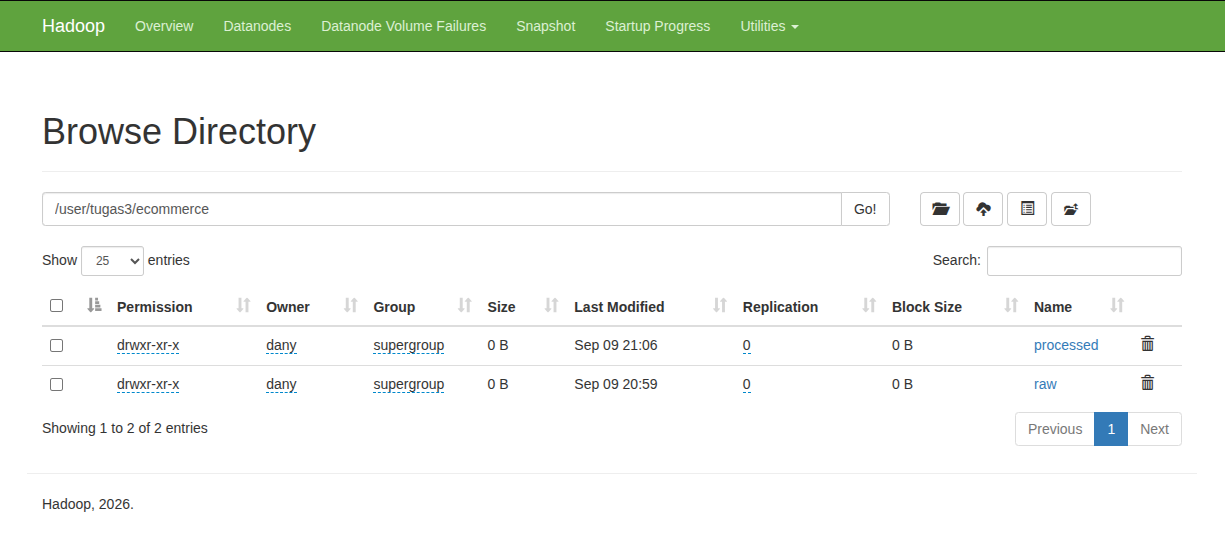
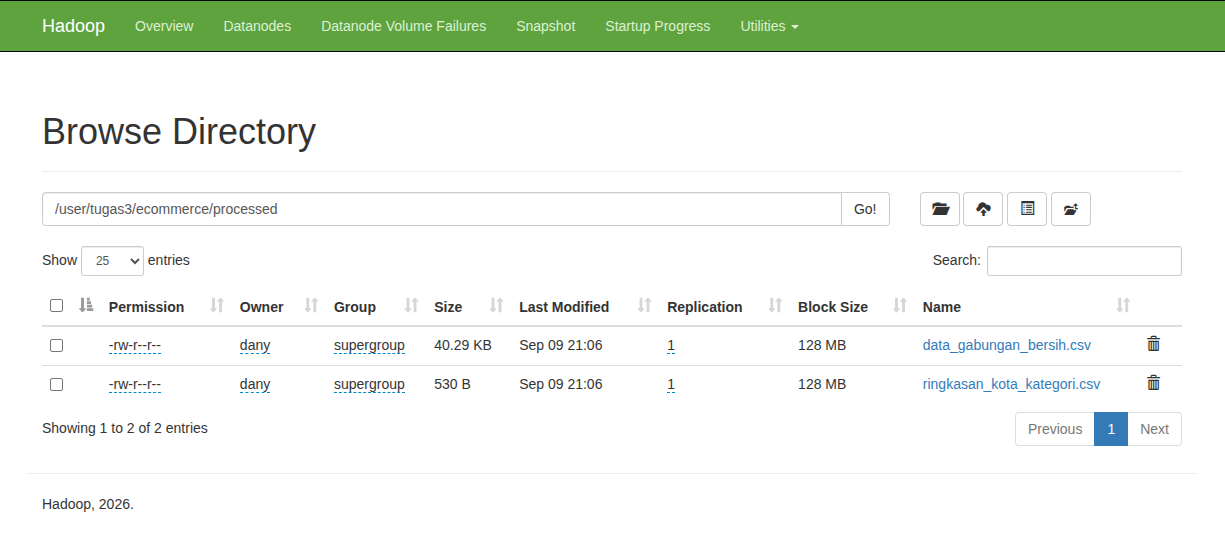
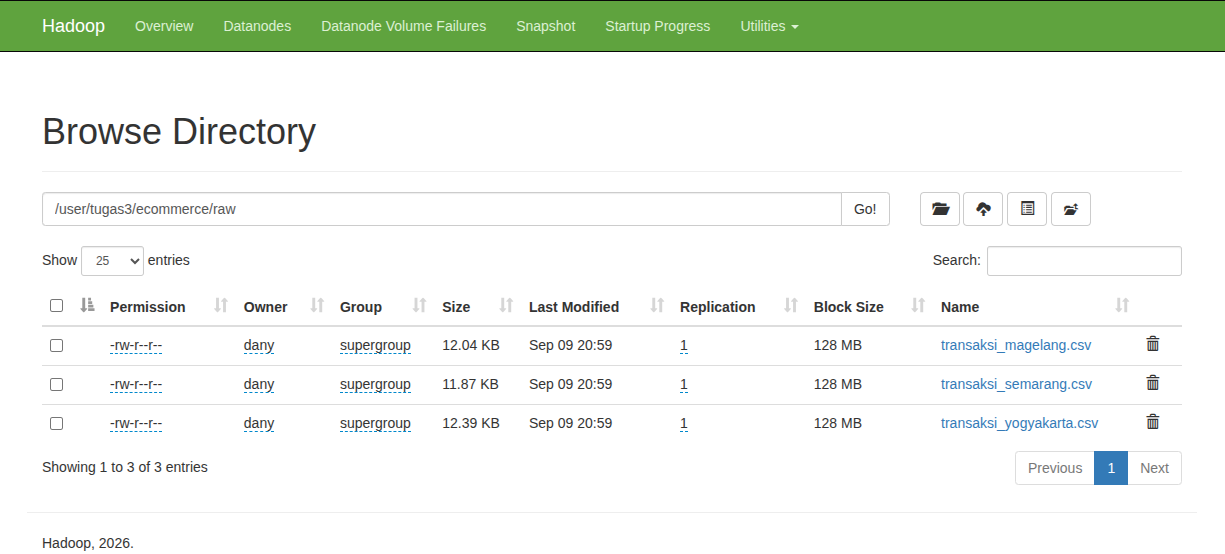

**2. Refleksi**

Memisahkan data raw dan processed di HDFS membuat pengelolaan data lebih rapi dan mudah. Data raw berisi data asli yang belum diolah, sehingga tetap bisa digunakan kembali jika terjadi kesalahan saat proses pengolahan. Sementara itu, data processed berisi data yang sudah dibersihkan, digabungkan, dihitung, atau diringkas sehingga lebih siap digunakan untuk analisis. Pemisahan kedua jenis data ini juga membantu pengguna membedakan data asli dan data hasil pengolahan. Selain itu, ketika diperlukan analisis baru, data processed dapat dibuat kembali dari data raw tanpa harus mencari data asli dari awal. Dengan struktur folder yang jelas, proses pengelolaan data di HDFS menjadi lebih terorganisir, mudah dipahami, dan lebih efisien, terutama ketika jumlah data semakin banyak.
